# 2. Data Understanding

## 2.1 Sumber Data
Dataset ECG200 diambil dari repositori **Time Series Classification** (timeseriesclassification.com), yang menyediakan data time series untuk benchmark klasifikasi. Dataset ini terdiri dari:
- 100 sampel latih dan 100 sampel uji,
- Setiap sampel berupa time series univariat dengan panjang 96,
- 2 kelas: **1 (normal)** dan **-1 (abnormal)**.

Data disimpan dalam format **ARFF** dan merepresentasikan segmen sinyal ECG dari pasien, yang telah dipotong dan dinormalisasi sebelumnya.

## 2.2 Eksplorasi Data Awal
Sebagai bagian dari Data Understanding, dilakukan:
- **Pemuatan dan konversi** file ARFF ke DataFrame,
- **Identifikasi label** (kolom pertama) dan 96 fitur waktu,
- **Pemeriksaan distribusi kelas**: seimbang (50–50) di data latih dan uji,
- **Visualisasi contoh sinyal per kelas** — menunjukkan perbedaan pola morfologi ECG,
- **Verifikasi kualitas data**: tidak ada missing value, semua series memiliki panjang 96, sesuai spesifikasi.

## 2.3 Relevansi terhadap Tujuan Analisis
Dataset ini relevan karena:
- **Mewakili masalah nyata**: deteksi dini kelainan jantung dari sinyal ECG,
- **Ukuran kecil namun cukup** untuk eksperimen klasifikasi time series,
- **Cocok untuk di-deploy** dalam aplikasi Streamlit sebagai demo prediksi.

## 2.4 Eksplorasi Data Awal (EDA)
### 1. Impor Library & Tentukan Path

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.io import arff

### 2. Muat Data ARFF & Tampilkan Kolom

In [3]:
# Path ke folder dataset
data_dir = "ECG200"

# Load file ARFF
train_path = os.path.join(data_dir, "ECG200_TRAIN.arff")
test_path = os.path.join(data_dir, "ECG200_TEST.arff")

# Baca data
data_train, meta_train = arff.loadarff(train_path)
data_test, meta_test = arff.loadarff(test_path)

# Konversi ke DataFrame
df_train = pd.DataFrame(data_train)
df_test = pd.DataFrame(data_test)

# Tampilkan info struktur
print("Kolom di TRAIN:", df_train.columns.tolist())
print("Kolom di TEST :", df_test.columns.tolist())
print("\nContoh data TRAIN:")
print(df_train.head(2))

Kolom di TRAIN: ['att1', 'att2', 'att3', 'att4', 'att5', 'att6', 'att7', 'att8', 'att9', 'att10', 'att11', 'att12', 'att13', 'att14', 'att15', 'att16', 'att17', 'att18', 'att19', 'att20', 'att21', 'att22', 'att23', 'att24', 'att25', 'att26', 'att27', 'att28', 'att29', 'att30', 'att31', 'att32', 'att33', 'att34', 'att35', 'att36', 'att37', 'att38', 'att39', 'att40', 'att41', 'att42', 'att43', 'att44', 'att45', 'att46', 'att47', 'att48', 'att49', 'att50', 'att51', 'att52', 'att53', 'att54', 'att55', 'att56', 'att57', 'att58', 'att59', 'att60', 'att61', 'att62', 'att63', 'att64', 'att65', 'att66', 'att67', 'att68', 'att69', 'att70', 'att71', 'att72', 'att73', 'att74', 'att75', 'att76', 'att77', 'att78', 'att79', 'att80', 'att81', 'att82', 'att83', 'att84', 'att85', 'att86', 'att87', 'att88', 'att89', 'att90', 'att91', 'att92', 'att93', 'att94', 'att95', 'att96', 'target']
Kolom di TEST : ['att1', 'att2', 'att3', 'att4', 'att5', 'att6', 'att7', 'att8', 'att9', 'att10', 'att11', 'att12', 'a

### 3. Identifikasi dan Ekstrak Label dengan Aman

In [4]:
# Coba cari nama kolom label: biasanya kolom pertama atau mengandung 'class'/'target'
possible_label_cols = [col for col in df_train.columns if 'class' in col.lower() or 'target' in col.lower()]

if possible_label_cols:
    label_col = possible_label_cols[0]
else:
    # Jika tidak ketemu, asumsikan kolom PERTAMA adalah label (umum di ARFF time series)
    label_col = df_train.columns[0]

print(f"Kolom label terdeteksi: '{label_col}'")

# Ekstrak fitur dan label
feature_cols = [col for col in df_train.columns if col != label_col]

X_train = df_train[feature_cols].values
y_train_raw = df_train[label_col].values

X_test = df_test[feature_cols].values
y_test_raw = df_test[label_col].values

print(f"\nJumlah fitur (time points): {len(feature_cols)}")
print(f"Shape X_train: {X_train.shape}")

Kolom label terdeteksi: 'target'

Jumlah fitur (time points): 96
Shape X_train: (100, 96)


### 4. Konversi Label dari Bytes ke Integer/String

In [5]:
# Fungsi untuk konversi label
def decode_labels(labels):
    if isinstance(labels[0], bytes):
        return np.array([lbl.decode('utf-8') for lbl in labels])
    else:
        return np.array(labels)

y_train = decode_labels(y_train_raw)
y_test = decode_labels(y_test_raw)

print("Label unik di train:", np.unique(y_train))
print("Label unik di test :", np.unique(y_test))

# Opsional: ubah ke integer jika labelnya '-1' dan '1'
if set(np.unique(y_train)) == {'-1', '1'}:
    y_train = y_train.astype(int)
    y_test = y_test.astype(int)
    print("\nLabel dikonversi ke integer.")

Label unik di train: ['-1' '1']
Label unik di test : ['-1' '1']

Label dikonversi ke integer.


### 5. EDA – Distribusi Kelas

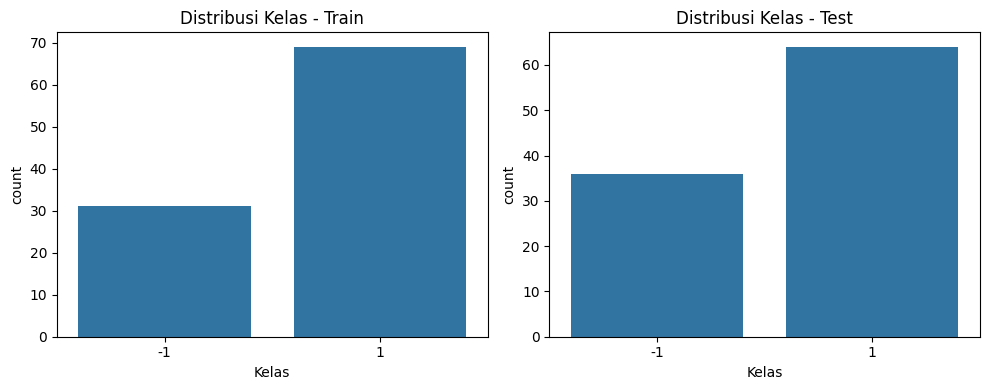

In [6]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.countplot(x=y_train)
plt.title("Distribusi Kelas - Train")
plt.xlabel("Kelas")

plt.subplot(1, 2, 2)
sns.countplot(x=y_test)
plt.title("Distribusi Kelas - Test")
plt.xlabel("Kelas")

plt.tight_layout()
plt.show()

### 6. EDA – Plot Contoh Time Series

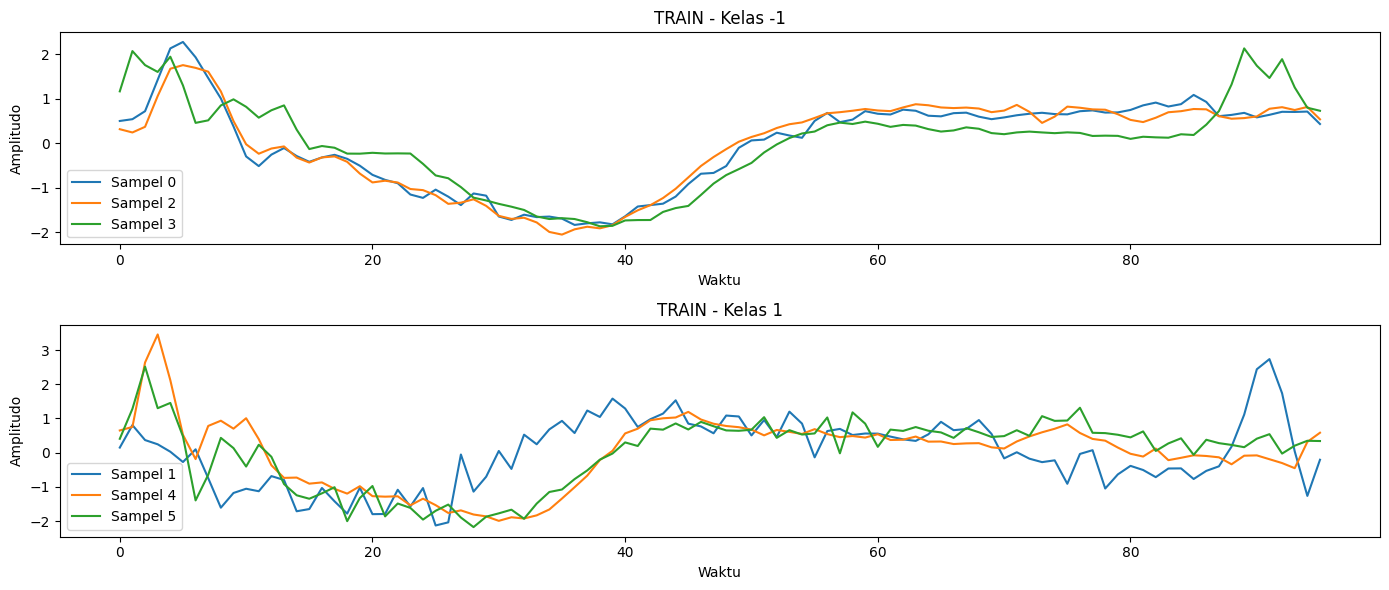

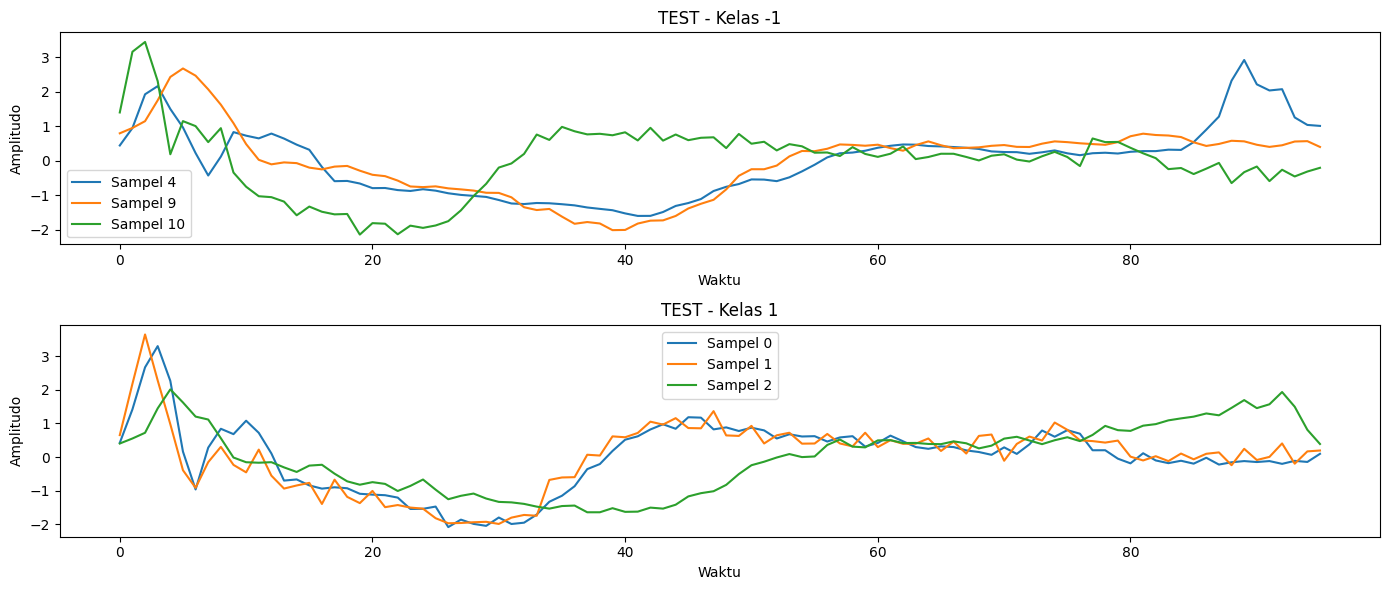

In [7]:
def plot_sample_time_series(X, y, title, n_samples=3):
    classes = np.unique(y)
    plt.figure(figsize=(14, 3 * len(classes)))
    
    for i, cls in enumerate(classes):
        idxs = np.where(y == cls)[0][:n_samples]
        plt.subplot(len(classes), 1, i + 1)
        for j, idx in enumerate(idxs):
            plt.plot(X[idx], label=f'Sampel {idx}')
        plt.title(f'{title} - Kelas {cls}')
        plt.xlabel('Waktu')
        plt.ylabel('Amplitudo')
        plt.legend()
    plt.tight_layout()
    plt.show()

plot_sample_time_series(X_train, y_train, "TRAIN")
plot_sample_time_series(X_test, y_test, "TEST")

### 7. Cek Missing Value

In [13]:
# Cek Missing Value
print("=== Cek Missing Value ===")
df_train_features = pd.DataFrame(X_train, columns=feature_cols)
df_test_features = pd.DataFrame(X_test, columns=feature_cols)

missing_train = df_train_features.isnull().sum().sum()
missing_test = df_test_features.isnull().sum().sum()

print(f"Missing value di TRAIN: {missing_train}")
print(f"Missing value di TEST : {missing_test}")

if missing_train == 0 and missing_test == 0:
    print("✅ Tidak ada missing value.")
else:
    print("⚠️ Terdapat missing value!")

=== Cek Missing Value ===
Missing value di TRAIN: 0
Missing value di TEST : 0
✅ Tidak ada missing value.


### 8. Cek Konsistensi Panjang Time Series

In [14]:
# Cek Konsistensi Panjang Time Series
print("\n=== Cek Panjang Time Series ===")
lengths_train = [len(x) for x in X_train]
lengths_test = [len(x) for x in X_test]

unique_lengths_train = np.unique(lengths_train)
unique_lengths_test = np.unique(lengths_test)

print(f"Panjang unik di TRAIN: {unique_lengths_train}")
print(f"Panjang unik di TEST : {unique_lengths_test}")

if len(unique_lengths_train) == 1 and len(unique_lengths_test) == 1:
    print(f"✅ Semua time series memiliki panjang {unique_lengths_train[0]}.")
else:
    print("⚠️ Ada variasi panjang time series!")


=== Cek Panjang Time Series ===
Panjang unik di TRAIN: [96]
Panjang unik di TEST : [96]
✅ Semua time series memiliki panjang 96.


### 9. Deteksi Nilai Ekstrem (Outlier Sederhana)


In [15]:
# Deteksi Nilai Ekstrem (Outlier Sederhana)
print("\n=== Cek Rentang Nilai (Min/Max) ===")
print(f"TRAIN - Min: {X_train.min():.3f}, Max: {X_train.max():.3f}")
print(f"TEST  - Min: {X_test.min():.3f}, Max: {X_test.max():.3f}")

# Cek apakah ada nilai yang sangat besar (misal > 10 atau < -10, tidak wajar untuk ECG)
extreme_train = np.any((X_train > 10) | (X_train < -10))
extreme_test = np.any((X_test > 10) | (X_test < -10))

if not extreme_train and not extreme_test:
    print("✅ Tidak ada nilai ekstrem yang mencurigakan.")
else:
    print("⚠️ Terdapat nilai ekstrem! Perlu investigasi lebih lanjut.")


=== Cek Rentang Nilai (Min/Max) ===
TRAIN - Min: -2.617, Max: 4.199
TEST  - Min: -3.014, Max: 4.148
✅ Tidak ada nilai ekstrem yang mencurigakan.


### 10.  Visualisasi Distribusi Nilai Amplitudo (Histogram)


=== Visualisasi Distribusi Nilai Amplitudo (Histogram) ===


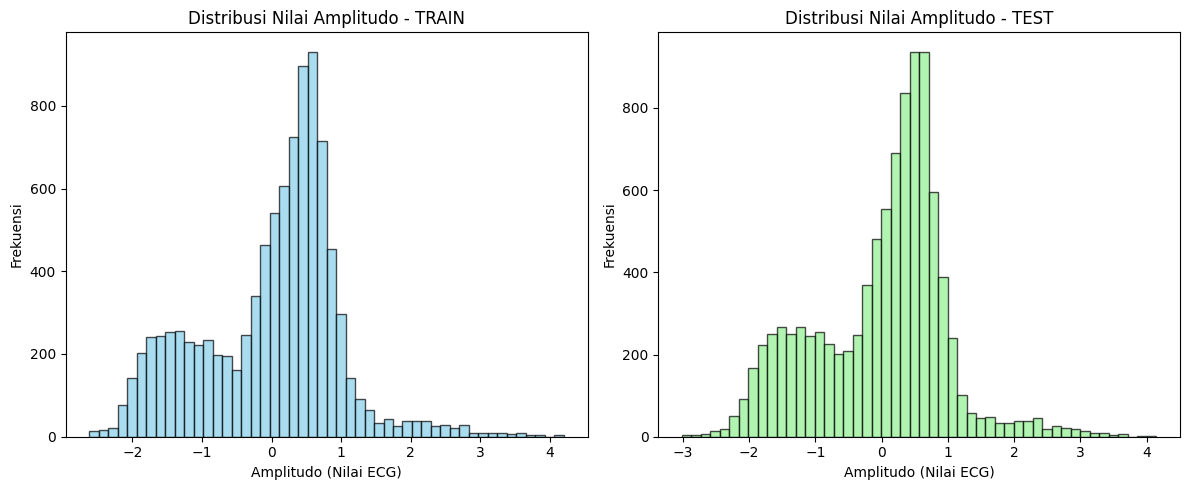


=== Statistik Ringkas (TRAIN) ===
    mean    std    min    max
0  0.708  0.594 -0.706  2.689
1  1.422  0.928 -1.101  3.535
2  2.039  1.047 -1.322  3.850
3  2.126  1.099 -1.076  4.199
4  1.552  0.955 -1.248  3.721


In [20]:
# Visualisasi Distribusi Nilai Amplitudo (Histogram)
print("\n=== Visualisasi Distribusi Nilai Amplitudo (Histogram) ===")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(X_train.flatten(), bins=50, color='skyblue', edgecolor='black', alpha=0.7)
plt.title("Distribusi Nilai Amplitudo - TRAIN")
plt.xlabel("Amplitudo (Nilai ECG)")
plt.ylabel("Frekuensi")

plt.subplot(1, 2, 2)
plt.hist(X_test.flatten(), bins=50, color='lightgreen', edgecolor='black', alpha=0.7)
plt.title("Distribusi Nilai Amplitudo - TEST")
plt.xlabel("Amplitudo (Nilai ECG)")
plt.ylabel("Frekuensi")

plt.tight_layout()
plt.show()
# Statistik Ringkas (Deskriptif) – TRAIN
print("\n=== Statistik Ringkas (TRAIN) ===")
stats_df = pd.DataFrame(X_train).describe().T[['mean', 'std', 'min', 'max']].round(3)
print(stats_df.head())  # Tampilkan 5 titik waktu pertama sebagai contoh